<a href="https://colab.research.google.com/github/bageya-dot/image-forensics-project/blob/main/Ivan_Bageya_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# STEP 1: INSTALL REQUIRED PACKAGES
# ============================================

!pip install pillow tqdm scikit-learn seaborn matplotlib kagglehub opencv-python-headless

print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:
# Standard libraries
import os
import json
import hashlib
import random
import shutil
from pathlib import Path
from datetime import datetime

# Data science
import numpy as np
import pandas as pd

# Image processing
from PIL import Image, ImageChops, ImageFile
import cv2

# Machine learning
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
import kagglehub

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All libraries imported
PyTorch version: 2.11.0+cpu
CUDA available: False


In [ ]:
print("📥 Downloading CASIA 2.0 dataset...")

try:
    path = kagglehub.dataset_download(
        "divg07/casia-20-image-tampering-detection-dataset"
    )
    print(f"✅ Dataset downloaded to: {path}")
except Exception as e:
    print(f"⚠️ Download error: {e}")
    print("Please ensure you have kagglehub installed and internet connection")

# Set paths
SRC_AU = Path(path) / "CASIA2" / "Au"
SRC_TP = Path(path) / "CASIA2" / "Tp"

print(f"Original images path: {SRC_AU}")
print(f"Tampered images path: {SRC_TP}")
print(f"Original images count: {len(list(SRC_AU.glob('*')))}")
print(f"Tampered images count: {len(list(SRC_TP.glob('*')))}")

📥 Downloading CASIA 2.0 dataset...
Using Colab cache for faster access to the 'casia-20-image-tampering-detection-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/casia-20-image-tampering-detection-dataset
Original images path: /kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Au
Tampered images path: /kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Tp
Original images count: 7492
Tampered images count: 5125


In [ ]:
# ============================================
# STEP 4: SPLIT DATASET (70% TRAIN, 15% VAL, 15% TEST)
# ============================================

BASE = Path("/content/casia_split")

# Create directory structure
for split in ["train", "val", "test"]:
    for cls in ["original", "tampered"]:
        (BASE / split / cls).mkdir(parents=True, exist_ok=True)

def split_and_copy(src_dir, label, split_ratios=(0.7, 0.15, 0.15)):
    """
    Split images and copy to respective directories
    """
    images = list(src_dir.glob("*"))
    random.shuffle(images)
    n = len(images)

    train_end = int(split_ratios[0] * n)
    val_end = int((split_ratios[0] + split_ratios[1]) * n)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, file_list in splits.items():
        for img in file_list:
            dest = BASE / split_name / label / img.name
            shutil.copy2(img, dest)

    return {k: len(v) for k, v in splits.items()}

print("📊 Splitting dataset...")

# Split original images
orig_counts = split_and_copy(SRC_AU, "original")
print(f"Original images - Train: {orig_counts['train']}, "
      f"Val: {orig_counts['val']}, Test: {orig_counts['test']}")

# Split tampered images
tampered_counts = split_and_copy(SRC_TP, "tampered")
print(f"Tampered images - Train: {tampered_counts['train']}, "
      f"Val: {tampered_counts['val']}, Test: {tampered_counts['test']}")

print("\n✅ Dataset split complete")
print(f"Total images: {sum(orig_counts.values()) + sum(tampered_counts.values())}")

📊 Splitting dataset...
Original images - Train: 5244, Val: 1124, Test: 1124
Tampered images - Train: 3587, Val: 769, Test: 769

✅ Dataset split complete
Total images: 12617


In [ ]:
# ============================================
# STEP 5: SHA-256 CRYPTOGRAPHIC INTEGRATION
# ============================================

class CryptographicVerifier:
    """
    Handles SHA-256 hashing for image integrity verification
    and maintains chain-of-custody audit logs
    """

    def __init__(self, log_file="chain_of_custody.json"):
        self.log_file = log_file
        self.chain_of_custody = []

        # Load existing log if available
        try:
            with open(log_file, 'r') as f:
                self.chain_of_custody = json.load(f)
            print(f"📂 Loaded {len(self.chain_of_custody)} chain-of-custody records")
        except (FileNotFoundError, json.JSONDecodeError):
            print("📂 Creating new chain-of-custody log")

    def generate_hash(self, file_path):
        """
        Generate SHA-256 hash of a file
        """
        sha256_hash = hashlib.sha256()

        try:
            with open(file_path, "rb") as f:
                # Read in chunks to handle large files
                for byte_block in iter(lambda: f.read(4096), b""):
                    sha256_hash.update(byte_block)
            return sha256_hash.hexdigest()
        except Exception as e:
            print(f"⚠️ Error hashing {file_path}: {e}")
            return None

    def record_event(self, image_path, action, actor, metadata=None):
        """
        Record a chain-of-custody event
        """
        image_path = Path(image_path)
        current_hash = self.generate_hash(image_path)

        if current_hash is None:
            return None

        entry = {
            "timestamp": datetime.now().isoformat(),
            "image": str(image_path.name),
            "image_path": str(image_path),
            "hash": current_hash,
            "action": action,
            "actor": actor,
            "metadata": metadata or {}
        }

        self.chain_of_custody.append(entry)
        self._save_log()

        return entry

    def _save_log(self):
        """Save chain-of-custody log to file"""
        try:
            with open(self.log_file, 'w') as f:
                json.dump(self.chain_of_custody, f, indent=2)
        except Exception as e:
            print(f"⚠️ Error saving log: {e}")

    def verify_integrity(self, image_path):
        """
        Verify if an image matches its stored hash
        """
        image_path = Path(image_path)
        current_hash = self.generate_hash(image_path)

        if current_hash is None:
            return {
                "valid": None,
                "status": "ERROR_HASHING",
                "current_hash": None
            }

        # Find stored hash for this image
        stored_entry = None
        for entry in reversed(self.chain_of_custody):
            if entry["image"] == image_path.name:
                stored_entry = entry
                break

        if stored_entry is None:
            return {
                "valid": None,
                "status": "NO_HASH_RECORD",
                "current_hash": current_hash
            }

        is_valid = (current_hash == stored_entry["hash"])

        return {
            "valid": is_valid,
            "status": "INTACT ✅" if is_valid else "TAMPERED ❌",
            "stored_hash": stored_entry["hash"],
            "current_hash": current_hash,
            "recorded_at": stored_entry["timestamp"]
        }

    def get_audit_trail(self, image_name):
        """
        Get full audit trail for a specific image
        """
        return [entry for entry in self.chain_of_custody
                if entry["image"] == image_name]

    def export_audit_report(self, output_file="audit_report.csv"):
        """
        Export full audit trail to CSV
        """
        df = pd.DataFrame(self.chain_of_custody)
        df.to_csv(output_file, index=False)
        print(f"📊 Audit report exported to {output_file}")
        return df

    def record_batch(self, image_paths, action, actor, metadata=None):
        """
        Record events for multiple images
        """
        results = []
        for img_path in tqdm(image_paths, desc="Recording chain of custody"):
            result = self.record_event(img_path, action, actor, metadata)
            if result:
                results.append(result)
        return results

print("🔐 CryptographicVerifier class defined")

# Initialize verifier
verifier = CryptographicVerifier("chain_of_custody.json")

print("\n📋 Recording chain of custody for all images...")

# Record all images in the dataset
all_images = []
for split in ["train", "val", "test"]:
    for cls in ["original", "tampered"]:
        img_dir = BASE / split / cls
        for img in img_dir.glob("*"):
            all_images.append(img)

print(f"📸 Found {len(all_images)} images to record")

# Record in batches (first 100 for quick test)
test_images = all_images[:100]
verifier.record_batch(
    test_images,
    action="DATASET_INGESTION",
    actor="research_pipeline",
    metadata={"dataset": "CASIA2", "split": "initial_ingest"}
)

print(f"✅ Recorded {len(verifier.chain_of_custody)} chain-of-custody entries")

🔐 CryptographicVerifier class defined
📂 Creating new chain-of-custody log

📋 Recording chain of custody for all images...
📸 Found 12617 images to record


Recording chain of custody: 100%|██████████| 100/100 [00:00<00:00, 182.49it/s]

✅ Recorded 100 chain-of-custody entries


In [ ]:
Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

ELA_BASE = Path("/content/casia_ela")

def precompute_ela():
    """
    Generate Error Level Analysis (ELA) images for all dataset images
    """
    for split in ["train", "val", "test"]:
        for cls in ["original", "tampered"]:
            src_dir = BASE / split / cls
            dst_dir = ELA_BASE / split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)

            images = list(src_dir.glob("*"))

            for img_path in tqdm(images, desc=f"ELA: {split}-{cls}"):
                try:
                    # Generate ELA
                    img = Image.open(img_path).convert("RGB")

                    # Save as JPEG with quality 90
                    temp_path = "/tmp/temp_ela.jpg"
                    img.save(temp_path, "JPEG", quality=90)
                    compressed = Image.open(temp_path)

                    # Difference
                    ela = ImageChops.difference(img, compressed)
                    ela = ela.point(lambda x: x * 10)

                    # Save as PNG
                    output_name = img_path.stem + ".png"
                    ela.save(dst_dir / output_name)

                except Exception as e:
                    continue

print("🔄 Generating ELA images...")
precompute_ela()
print("✅ ELA precomputation complete")

🔄 Generating ELA images...


ELA: test-tampered: 100%|██████████| 769/769 [01:27<00:00,  8.81it/s]

✅ ELA precomputation complete


In [ ]:
# ============================================
# STEP 7: DATASET LOADER WITH CRYPTOGRAPHIC VERIFICATION
# ============================================

class SecureELADataset(Dataset):
    """
    Dataset that loads ELA images with optional cryptographic verification
    """

    def __init__(self, root, verifier=None, verify_hashes=False):
        self.samples = []
        self.verifier = verifier
        self.verify_hashes = verify_hashes

        for label, cls in enumerate(["original", "tampered"]):
            img_dir = Path(root) / cls
            for img_path in img_dir.glob("*"):
                self.samples.append((img_path, label))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        print(f"📊 Loaded {len(self.samples)} images from {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Optional integrity verification
        if self.verifier and self.verify_hashes:
            verification = self.verifier.verify_integrity(img_path)
            if verification["status"] == "TAMPERED ❌":
                print(f"⚠️ Integrity warning: {img_path.name} may be tampered!")

        # Load image
        img = Image.open(img_path).convert("RGB")
        return self.transform(img), label

# Create data loaders
train_dataset = SecureELADataset(
    ELA_BASE / "train",
    verifier=verifier,
    verify_hashes=False  # Set to True for verification during training
)

val_dataset = SecureELADataset(
    ELA_BASE / "val",
    verifier=verifier,
    verify_hashes=False
)

test_dataset = SecureELADataset(
    ELA_BASE / "test",
    verifier=verifier,
    verify_hashes=False
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\n✅ DataLoaders created:")
print(f"  Training: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")
print(f"  Test: {len(test_dataset)} images")

📊 Loaded 8829 images from /content/casia_ela/train
📊 Loaded 1893 images from /content/casia_ela/val
📊 Loaded 1892 images from /content/casia_ela/test

✅ DataLoaders created:
  Training: 8829 images
  Validation: 1893 images
  Test: 1892 images


In [ ]:
# ============================================
# STEP 8: MOBILENETV2 MODEL ARCHITECTURE
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

def create_model():
    """
    Create MobileNetV2 with transfer learning
    """
    # Load pretrained MobileNetV2
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last few layers for fine-tuning
    for param in model.features[-3:].parameters():
        param.requires_grad = True

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(1280, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

    return model

model = create_model().to(device)

# Print model summary
print("\n📌 MODEL ARCHITECTURE:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Frozen parameters: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

# Count layers
total_layers = 0
trainable_layers = 0
for name, module in model.named_modules():
    if len(list(module.children())) == 0:  # Leaf module
        total_layers += 1
        if any(p.requires_grad for p in module.parameters()):
            trainable_layers += 1

print(f"  Total layers: {total_layers}")
print(f"  Trainable layers: {trainable_layers}")

🖥️ Using device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s]



📌 MODEL ARCHITECTURE:
  Total parameters: 2,552,065
  Trainable parameters: 1,534,273
  Frozen parameters: 1,017,792
  Total layers: 144
  Trainable layers: 16


In [ ]:
# ============================================
# STEP 9: TRAIN MODEL
# ============================================

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([2.0]).to(device)
)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

THRESHOLD = 0.3
EPOCHS = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
print(f"  Threshold: {THRESHOLD}")
print(f"  Learning rate: {optimizer.param_groups[0]['lr']}\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # ----- TRAINING -----
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for x, y in tqdm(train_loader, desc="Training"):
        x = x.to(device)
        y = y.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = (torch.sigmoid(logits) > THRESHOLD).int()
        train_correct += (preds == y.int()).sum().item()
        train_total += y.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ----- VALIDATION -----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validation"):
            x = x.to(device)
            y = y.float().unsqueeze(1).to(device)

            logits = model(x)
            loss = criterion(logits, y)

            val_loss += loss.item() * x.size(0)
            preds = (torch.sigmoid(logits) > THRESHOLD).int()
            val_correct += (preds == y.int()).sum().item()
            val_total += y.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # ----- RECORD HISTORY -----
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Update learning rate
    scheduler.step(val_loss)
    print(f"Learning rate: {optimizer.param_groups[0]['lr']:.6f}\n")

print("✅ Training complete!")


🚀 Starting training for 10 epochs...
  Threshold: 0.3
  Learning rate: 0.0001

Epoch 1/10
----------------------------------------


Validation: 100%|██████████| 60/60 [02:28<00:00,  2.48s/it]


Train Loss: 0.4634 | Train Acc: 0.7860
Val   Loss: 0.3392 | Val   Acc: 0.8875
Learning rate: 0.000100

Epoch 2/10
----------------------------------------


Validation: 100%|██████████| 60/60 [02:35<00:00,  2.60s/it]


Train Loss: 0.3214 | Train Acc: 0.8714
Val   Loss: 0.3309 | Val   Acc: 0.8843
Learning rate: 0.000100

Epoch 3/10
----------------------------------------


...

Train Loss: 0.1484 | Train Acc: 0.9340
Val   Loss: 0.4414 | Val   Acc: 0.9017
Learning rate: 0.000050

Epoch 9/10
----------------------------------------


Validation: 100%|██████████| 60/60 [02:19<00:00,  2.33s/it]


Train Loss: 0.1152 | Train Acc: 0.9522
Val   Loss: 0.3933 | Val   Acc: 0.9044
Learning rate: 0.000050

Epoch 10/10
----------------------------------------


Validation: 100%|██████████| 60/60 [02:20<00:00,  2.35s/it]

Train Loss: 0.1004 | Train Acc: 0.9568
Val   Loss: 0.4342 | Val   Acc: 0.8933
Learning rate: 0.000050

✅ Training complete!


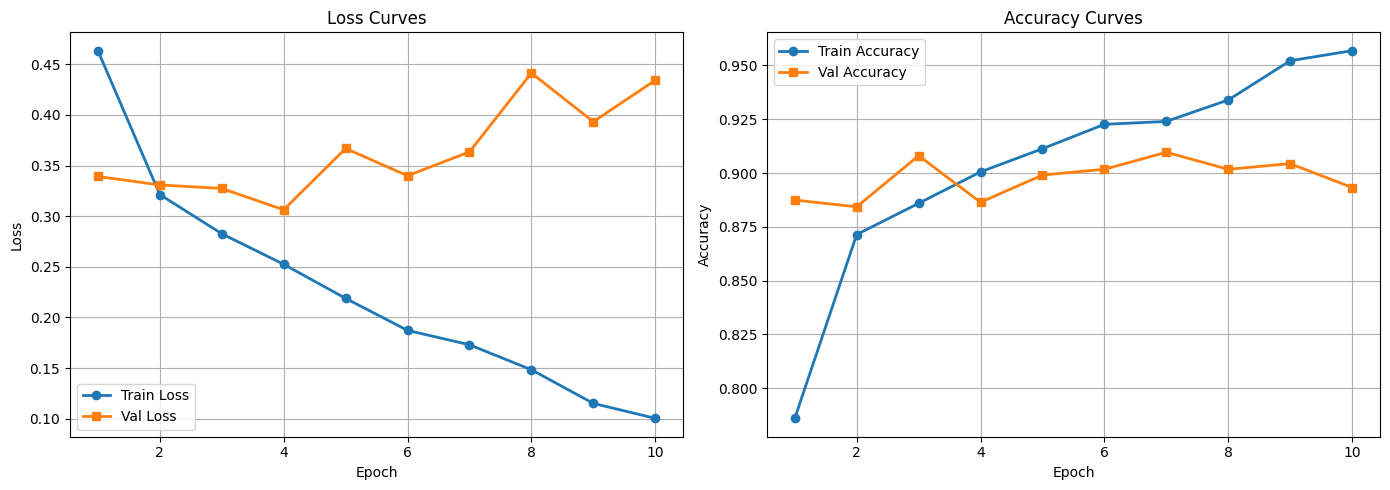

📊 Training curves saved to training_curves.png


In [ ]:
# ============================================
# STEP 10: VISUALIZE TRAINING CURVES
# ============================================

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs, history["train_loss"], marker='o', label="Train Loss", linewidth=2)
ax1.plot(epochs, history["val_loss"], marker='s', label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(True)

# Accuracy curves
ax2.plot(epochs, history["train_acc"], marker='o', label="Train Accuracy", linewidth=2)
ax2.plot(epochs, history["val_acc"], marker='s', label="Val Accuracy", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()
print("📊 Training curves saved to training_curves.png")


📊 Evaluating model on test set...


Testing: 100%|██████████| 60/60 [02:42<00:00,  2.72s/it]



📈 FINAL TEST METRICS:


,Metric,Score
0,Accuracy,0.902748
1,Precision,0.834862
2,Recall,0.947917
3,F1 Score,0.887805
4,AUC,0.969017


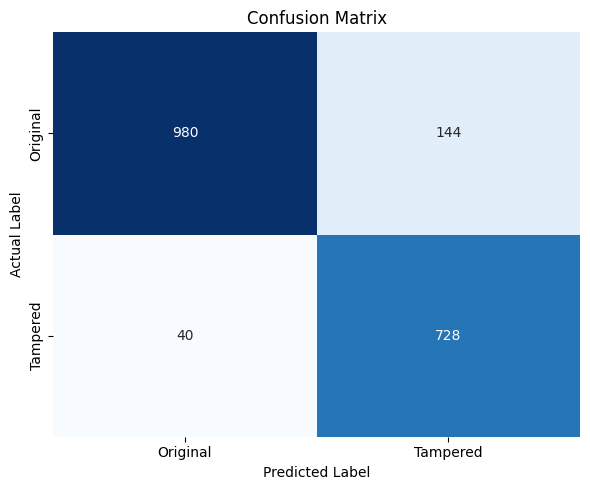

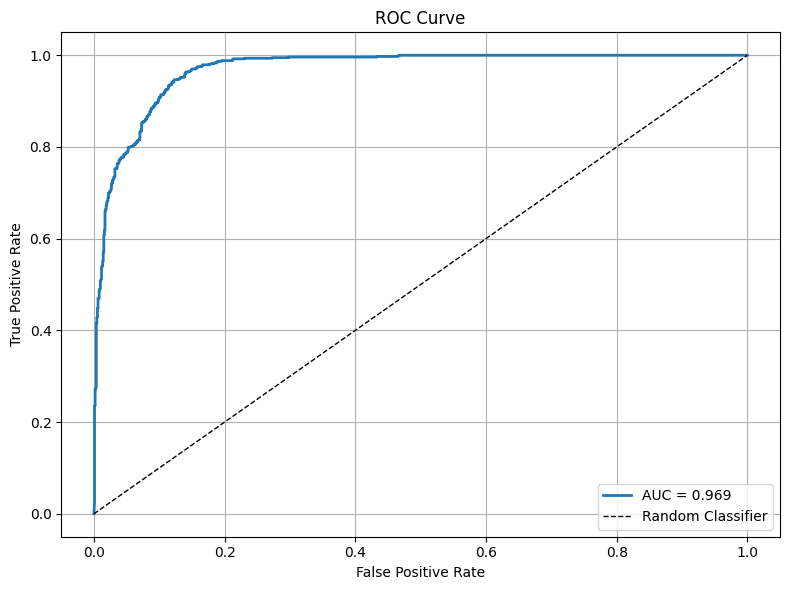

In [ ]:
# ============================================
# STEP 11: MODEL EVALUATION
# ============================================

print("\n📊 Evaluating model on test set...")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int().cpu().numpy()

        all_preds.extend(preds.flatten())
        all_labels.extend(y.numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())

# Calculate metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    "Score": [acc, prec, rec, f1, auc]
})

print("\n📈 FINAL TEST METRICS:")
display(metrics_df)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    cbar=False,
    xticklabels=["Original", "Tampered"],
    yticklabels=["Original", "Tampered"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

In [ ]:
# ============================================
# STEP 12: GRAD-CAM EXPLAINABLE AI
# ============================================

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping
    Visualizes regions influencing model decisions
    """

    def __init__(self, model, target_layer_name='features.18'):
        self.model = model
        self.gradients = None
        self.activations = None

        # Find the target layer
        self.target_layer = self._find_layer(model, target_layer_name)

        # Register hooks
        self._register_hooks()

        print(f"🎯 Grad-CAM initialized with target layer: {target_layer_name}")

    def _find_layer(self, model, layer_name):
        """Find a layer by name"""
        parts = layer_name.split('.')
        current = model
        for part in parts:
            if part.isdigit():
                current = current[int(part)]
            else:
                current = getattr(current, part)
        return current

    def _register_hooks(self):
        """Register hooks to capture gradients and activations"""
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor):
        """
        Generate Grad-CAM heatmap for a given input
        """
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)

        # Zero gradients
        self.model.zero_grad()

        # Backward pass (use the output logit directly)
        output[0, 0].backward(retain_graph=True)

        # Get gradients and activations
        gradients = self.gradients
        activations = self.activations

        if gradients is None or activations is None:
            print("⚠️ Gradients or activations not captured")
            return np.zeros((224, 224))

        # Pool gradients (Global Average Pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight activations by pooled gradients
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        # Average over channels
        heatmap = torch.mean(activations, dim=1).squeeze()

        # ReLU activation
        heatmap = torch.relu(heatmap)

        # Normalize to [0, 1]
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap.cpu().numpy()

    def overlay_heatmap(self, image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
        """
        Overlay heatmap on original image
        """
        # Convert tensor to numpy if needed
        if isinstance(image, torch.Tensor):
            # Unnormalize
            image = image.cpu().squeeze()

            # If normalized, denormalize
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image * std + mean

            # Convert to numpy and scale
            image = image.permute(1, 2, 0).numpy()
            image = np.clip(image, 0, 1)
            image = (image * 255).astype(np.uint8)

        # Resize heatmap to image dimensions
        heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

        # Apply colormap
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)

        # Superimpose
        overlay = cv2.addWeighted(
            image, 1 - alpha,
            heatmap_colored, alpha,
            0
        )

        return overlay

# Initialize Grad-CAM
grad_cam = GradCAM(model, target_layer_name='features.18')

print("✅ Grad-CAM initialized successfully")

🎯 Grad-CAM initialized with target layer: features.18
✅ Grad-CAM initialized successfully



🎯 Generating Grad-CAM visualizations...

📸 ORIGINAL IMAGE:


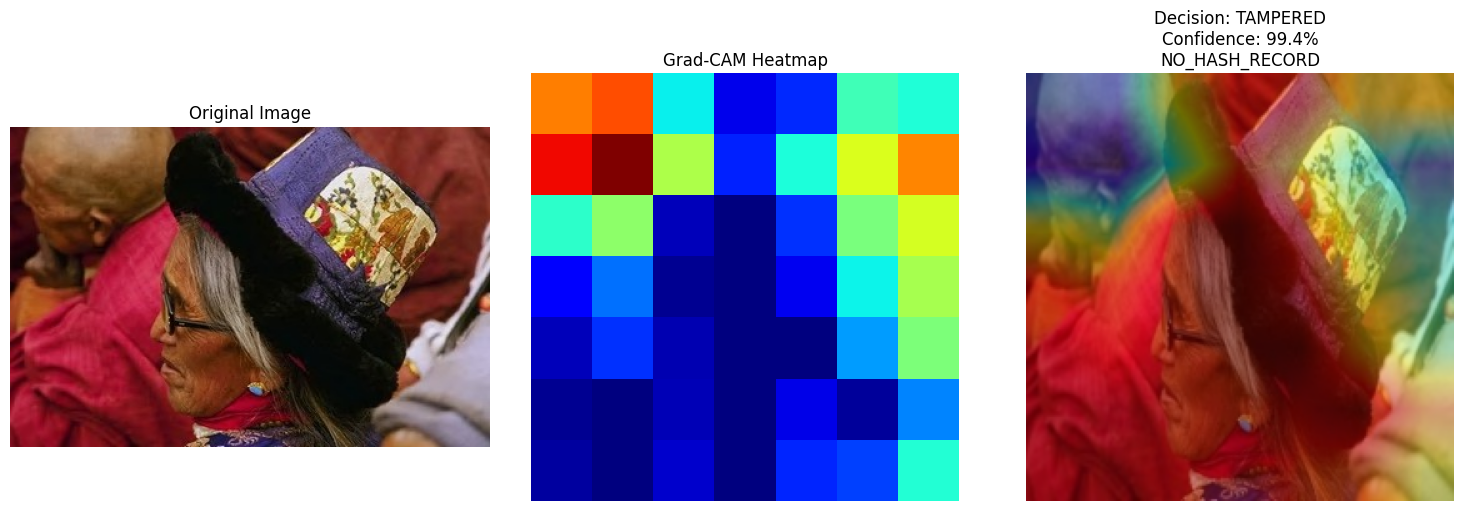


🎨 TAMPERED IMAGE:


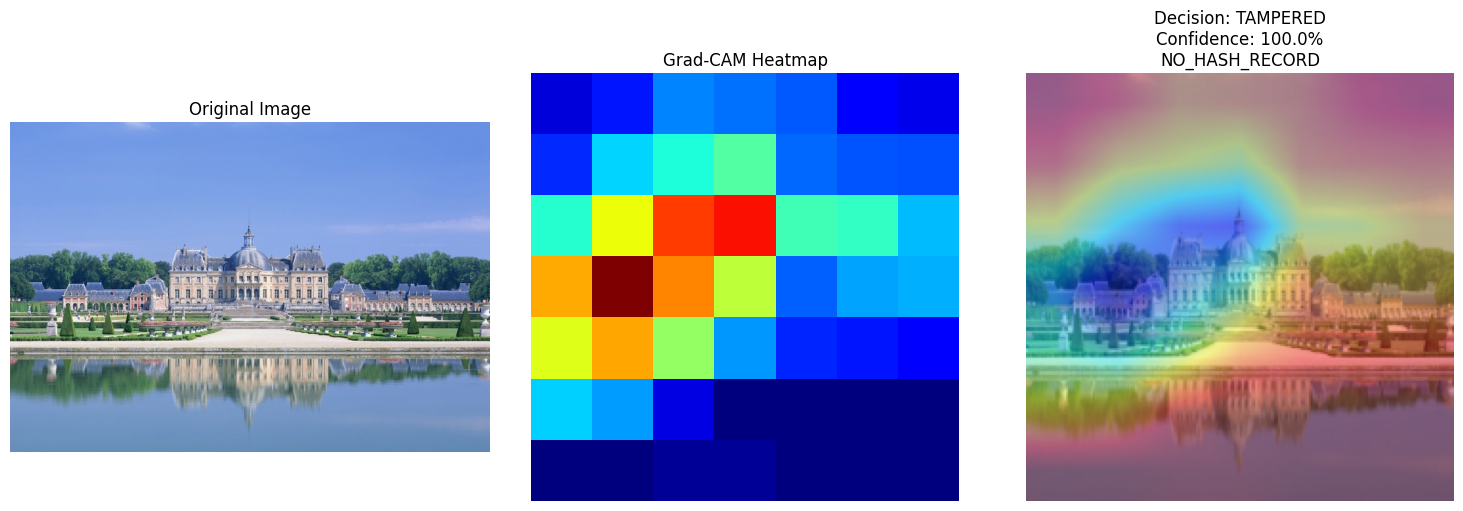

In [ ]:
# ============================================
# STEP 13: VISUALIZE PREDICTIONS WITH GRAD-CAM
# ============================================

def visualize_with_gradcam(image_path, model, grad_cam, threshold=0.3, save=False):
    """
    Visualize a single image with Grad-CAM explanation
    """
    # Load original image
    original_img = Image.open(image_path).convert("RGB")
    img_display = np.array(original_img)

    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(original_img).unsqueeze(0).to(device)

    # Get prediction
    model.eval()
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
        pred = "TAMPERED" if prob > threshold else "AUTHENTIC"
        confidence = prob if prob > threshold else 1 - prob

    # Generate Grad-CAM heatmap
    heatmap = grad_cam.generate_heatmap(input_tensor)

    # Create overlay
    overlay = grad_cam.overlay_heatmap(input_tensor, heatmap, alpha=0.4)

    # Verify integrity
    verification = verifier.verify_integrity(image_path)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img_display)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[1].axis('off')

    # Overlay
    axes[2].imshow(overlay)
    axes[2].set_title(f"Decision: {pred}\nConfidence: {confidence*100:.1f}%\n{verification['status']}", fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()

    if save:
        output_dir = Path("gradcam_outputs")
        output_dir.mkdir(exist_ok=True)
        plt.savefig(output_dir / f"{image_path.stem}_gradcam.png", dpi=200)

    plt.show()

    return {
        "image": image_path.name,
        "prediction": pred,
        "confidence": confidence,
        "verification": verification,
        "heatmap": heatmap,
        "overlay": overlay
    }

# Test on sample images
print("\n🎯 Generating Grad-CAM visualizations...\n")

# Original sample
print("📸 ORIGINAL IMAGE:")
orig_sample = list((BASE / "test" / "original").glob("*"))[0]
result_orig = visualize_with_gradcam(orig_sample, model, grad_cam, save=True)

# Tampered sample
print("\n🎨 TAMPERED IMAGE:")
tamp_sample = list((BASE / "test" / "tampered").glob("*"))[0]
result_tamp = visualize_with_gradcam(tamp_sample, model, grad_cam, save=True)

In [ ]:
# ============================================
# STEP 14: GENERATE FORENSIC REPORT
# ============================================

def generate_forensic_report(image_path, model, grad_cam, verifier):
    """
    Generate comprehensive forensic report for court presentation
    """
    report = {}

    # 1. Image Information
    report["image_name"] = image_path.name
    report["image_path"] = str(image_path)
    img = Image.open(image_path)
    report["image_size"] = f"{img.size[0]}x{img.size[1]}"
    report["image_format"] = img.format

    # 2. Cryptographic Verification
    verification = verifier.verify_integrity(image_path)
    report["hash_verified"] = verification["status"]
    if verification["valid"] is not None:
        report["stored_hash"] = verification.get("stored_hash", "N/A")
        report["current_hash"] = verification.get("current_hash", "N/A")
    report["chain_of_custody"] = verifier.get_audit_trail(image_path.name)

    # 3. AI Analysis
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()

    report["ai_confidence"] = prob
    report["ai_verdict"] = "TAMPERED" if prob > THRESHOLD else "AUTHENTIC"

    # 4. Grad-CAM Explanation
    heatmap = grad_cam.generate_heatmap(input_tensor)
    report["heatmap_generated"] = True
    report["heatmap_shape"] = str(heatmap.shape)

    # 5. Summary
    report["generated_at"] = datetime.now().isoformat()

    return report

def print_forensic_report(report):
    """
    Print a formatted forensic report
    """
    print("\n" + "="*60)
    print("🔬 FORENSIC IMAGE ANALYSIS REPORT")
    print("="*60)
    print(f"\n📷 Image: {report['image_name']}")
    print(f"📏 Size: {report['image_size']}")
    print(f"📂 Format: {report.get('image_format', 'N/A')}")

    print(f"\n🔐 CRYPTOGRAPHIC VERIFICATION")
    print("-" * 40)
    print(f"  Status: {report['hash_verified']}")
    if 'stored_hash' in report:
        print(f"  Stored Hash: {report['stored_hash'][:16]}...")
        print(f"  Current Hash: {report['current_hash'][:16]}...")
    print(f"  Chain of Custody: {len(report.get('chain_of_custody', []))} records")

    print(f"\n🤖 AI ANALYSIS")
    print("-" * 40)
    print(f"  Verdict: {report['ai_verdict']}")
    print(f"  Confidence: {report['ai_confidence']*100:.1f}%")

    print(f"\n📊 EXPLANATION (Grad-CAM)")
    print("-" * 40)
    print(f"  Heatmap Generated: {report['heatmap_generated']}")
    print(f"  Heatmap Size: {report.get('heatmap_shape', 'N/A')}")

    print(f"\n⏰ Generated: {report.get('generated_at', 'N/A')}")
    print("\n" + "="*60)

# Generate report for a sample
print("\n📋 Generating forensic report...")
report = generate_forensic_report(tamp_sample, model, grad_cam, verifier)
print_forensic_report(report)

# Save report as JSON
with open("forensic_report.json", 'w') as f:
    json.dump(report, f, indent=2, default=str)
print("\n💾 Report saved to forensic_report.json")


📋 Generating forensic report...

🔬 FORENSIC IMAGE ANALYSIS REPORT

📷 Image: Tp_S_NRD_S_B_arc20003_arc20003_01456.tif
📏 Size: 800x549
📂 Format: TIFF

🔐 CRYPTOGRAPHIC VERIFICATION
----------------------------------------
  Status: NO_HASH_RECORD
  Chain of Custody: 0 records

🤖 AI ANALYSIS
----------------------------------------
  Verdict: TAMPERED
  Confidence: 100.0%

📊 EXPLANATION (Grad-CAM)
----------------------------------------
  Heatmap Generated: True
  Heatmap Size: (7, 7)

⏰ Generated: 2026-06-23T11:24:09.608087


💾 Report saved to forensic_report.json


In [ ]:
# ============================================
# STEP 15: EXPORT CHAIN OF CUSTODY
# ============================================

print("\n📊 Exporting chain-of-custody audit trail...")

# Export full audit trail
audit_df = verifier.export_audit_report("audit_report.csv")

# Display summary
print(f"\n📋 Audit Trail Summary:")
print(f"  Total records: {len(audit_df)}")
print(f"  Unique images: {audit_df['image'].nunique()}")
print(f"  Unique actions: {audit_df['action'].unique().tolist()}")
print(f"  Time range: {audit_df['timestamp'].min()} to {audit_df['timestamp'].max()}")

# Display first few records
print("\n📋 Sample records:")
display(audit_df.head(10))

print("\n✅ Audit trail exported to audit_report.csv")


📊 Exporting chain-of-custody audit trail...
📊 Audit report exported to audit_report.csv

📋 Audit Trail Summary:
  Total records: 100
  Unique images: 100
  Unique actions: ['DATASET_INGESTION']
  Time range: 2026-06-23T07:14:23.386931 to 2026-06-23T07:14:23.927882

📋 Sample records:


,timestamp,image,image_path,hash,action,actor,metadata
0,2026-06-23T07:14:23.386931,Au_ind_00087.jpg,/content/casia_split/train/original/Au_ind_000...,1b71d1ee5d6f1a80683d7f9f1ff8163a8b8219640ef649...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
1,2026-06-23T07:14:23.393919,Au_arc_30142.jpg,/content/casia_split/train/original/Au_arc_301...,f3e1212fd10016856adf34c74329788fb0f782a73fb7ba...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
2,2026-06-23T07:14:23.398652,Au_sec_30479.jpg,/content/casia_split/train/original/Au_sec_304...,691e687c71b0b03d9cf6b3ff2ace03042b17f3c3795a3c...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
3,2026-06-23T07:14:23.403774,Au_ind_30144.jpg,/content/casia_split/train/original/Au_ind_301...,05795a60b5fed76fb3e358a0e47c351e497f99ddbad7f4...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
4,2026-06-23T07:14:23.409200,Au_sec_30244.jpg,/content/casia_split/train/original/Au_sec_302...,39f4de525c0b09747d9915427359416abce2cd11e6a020...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
5,2026-06-23T07:14:23.420465,Au_arc_00042.jpg,/content/casia_split/train/original/Au_arc_000...,235f53a515fb605981aa102340950b96cb7b6c93d1116f...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
6,2026-06-23T07:14:23.427888,Au_pla_30639.jpg,/content/casia_split/train/original/Au_pla_306...,6e019dbe02647edd87716c2bdce3190062cdd7354cbb93...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
7,2026-06-23T07:14:23.435053,Au_pla_30708.jpg,/content/casia_split/train/original/Au_pla_307...,c235c5583dc2d2d638f0abb82d91c50db31fafa0c6a3d0...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
8,2026-06-23T07:14:23.440399,Au_nat_00012.jpg,/content/casia_split/train/original/Au_nat_000...,f39a7df5f9e14a2d9fd0b44d024ba193ff42544b2ef5fe...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"
9,2026-06-23T07:14:23.451660,Au_ani_20018.jpg,/content/casia_split/train/original/Au_ani_200...,06e6535c2624ebec4fa26f68e1caadd00e9d44b3dfd5f1...,DATASET_INGESTION,research_pipeline,"{'dataset': 'CASIA2', 'split': 'initial_ingest'}"



✅ Audit trail exported to audit_report.csv


In [ ]:
# ============================================
# STEP 16: SAVE MODEL AND CONFIGURATION
# ============================================

MODEL_PATH = "/content/mobilenet_ela_final.pth"

torch.save({
    "epoch": EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "threshold": THRESHOLD,
    "train_acc": history["train_acc"][-1],
    "val_acc": history["val_acc"][-1],
    "test_acc": acc,
    "test_f1": f1,
    "config": {
        "model": "mobilenet_v2",
        "input_size": 224,
        "pretrained": True,
        "freeze_layers": True,
        "epochs": EPOCHS,
        "threshold": THRESHOLD
    }
}, MODEL_PATH)

print(f"✅ Model saved to {MODEL_PATH}")

# Save configuration summary
config_summary = {
    "model": "mobilenet_v2",
    "dataset": "CASIA2",
    "split": {"train": 70, "val": 15, "test": 15},
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "epochs": EPOCHS,
    "threshold": THRESHOLD,
    "test_metrics": {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "auc": auc
    },
    "cryptographic": {
        "hash_algorithm": "SHA-256",
        "chain_of_custody_records": len(audit_df)
    },
    "xai": {
        "method": "Grad-CAM",
        "target_layer": "features.18"
    },
    "timestamp": datetime.now().isoformat()
}

with open("model_config.json", 'w') as f:
    json.dump(config_summary, f, indent=2)

print("✅ Configuration saved to model_config.json")

✅ Model saved to /content/mobilenet_ela_final.pth
✅ Configuration saved to model_config.json


In [ ]:
# ============================================
# STEP 17: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("🎉 INTEGRATED PIPELINE COMPLETE")
print("="*60)

print("\n📊 SUMMARY:")
print("-"*40)
print(f"  Dataset: CASIA 2.0")
print(f"  Total Images: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"  Training: {len(train_dataset)}")
print(f"  Validation: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

print(f"\n  Model: MobileNetV2 (transfer learning)")
print(f"  Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

print(f"\n  Test Performance:")
print(f"    Accuracy:  {acc:.4f}")
print(f"    Precision: {prec:.4f}")
print(f"    Recall:    {rec:.4f}")
print(f"    F1 Score:  {f1:.4f}")
print(f"    AUC:       {auc:.4f}")

print(f"\n  Cryptographic:")
print(f"    Algorithm: SHA-256")
print(f"    Records: {len(audit_df)}")

print(f"\n  Explainable AI:")
print(f"    Method: Grad-CAM")
print(f"    Layer: features.18")

print(f"\n  Outputs:")
print(f"    Model: {MODEL_PATH}")
print(f"    Config: model_config.json")
print(f"    Audit: audit_report.csv")
print(f"    Report: forensic_report.json")
print(f"    Training Curves: training_curves.png")
print(f"    Confusion Matrix: confusion_matrix.png")
print(f"    ROC Curve: roc_curve.png")
print(f"    Grad-CAM Outputs: gradcam_outputs/")

print("\n" + "="*60)
print("✅ Ready!")


🎉 INTEGRATED PIPELINE COMPLETE

📊 SUMMARY:
----------------------------------------
  Dataset: CASIA 2.0
  Total Images: 12614
  Training: 8829
  Validation: 1893
  Test: 1892

  Model: MobileNetV2 (transfer learning)
  Trainable Parameters: 1,534,273

  Test Performance:
    Accuracy:  0.9027
    Precision: 0.8349
    Recall:    0.9479
    F1 Score:  0.8878
    AUC:       0.9690

  Cryptographic:
    Algorithm: SHA-256
    Records: 100

  Explainable AI:
    Method: Grad-CAM
    Layer: features.18

  Outputs:
    Model: /content/mobilenet_ela_final.pth
    Config: model_config.json
    Audit: audit_report.csv
    Report: forensic_report.json
    Training Curves: training_curves.png
    Confusion Matrix: confusion_matrix.png
    ROC Curve: roc_curve.png
    Grad-CAM Outputs: gradcam_outputs/

✅ Ready!
